# 02 — Plot the Signals
Visualise raw IQ data to understand what different radar signals look like.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from radar.data import load_radchar

DATA_PATH = "../data/RadChar-Baseline.h5"

In [2]:
iq, labels = load_radchar(DATA_PATH)

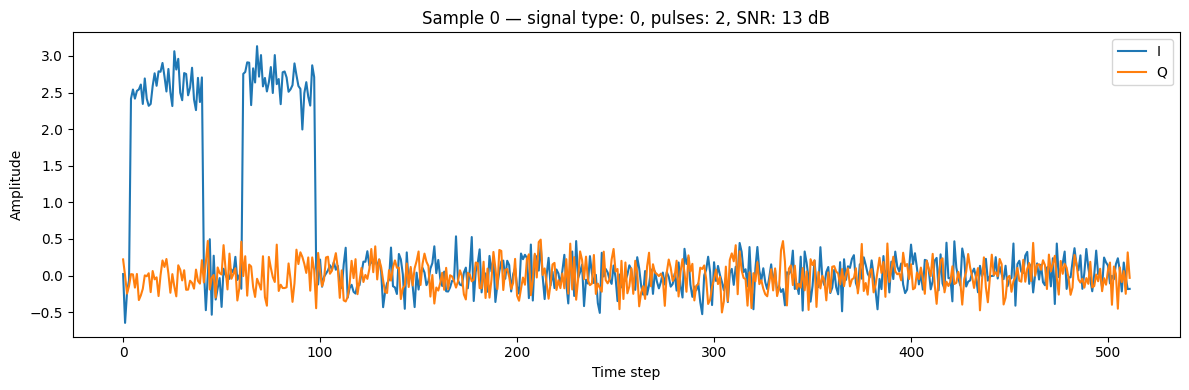

In [3]:
# pick the first sample and split into I and Q
sample = iq[0]
I = sample.real   # in-phase component
Q = sample.imag   # quadrature component

time = np.arange(512)  # just 0 to 511 — the 512 time steps

# plot I and Q over time
plt.figure(figsize=(12, 4))
plt.plot(time, I, label='I')
plt.plot(time, Q, label='Q')
plt.title(f'Sample 0 — signal type: {labels[0]["signal_type"]}, pulses: {labels[0]["number_of_pulses"]}, SNR: {labels[0]["signal_to_noise_ratio"]} dB')
plt.xlabel('Time step')
plt.ylabel('Amplitude')
plt.legend()
plt.tight_layout()
plt.show()

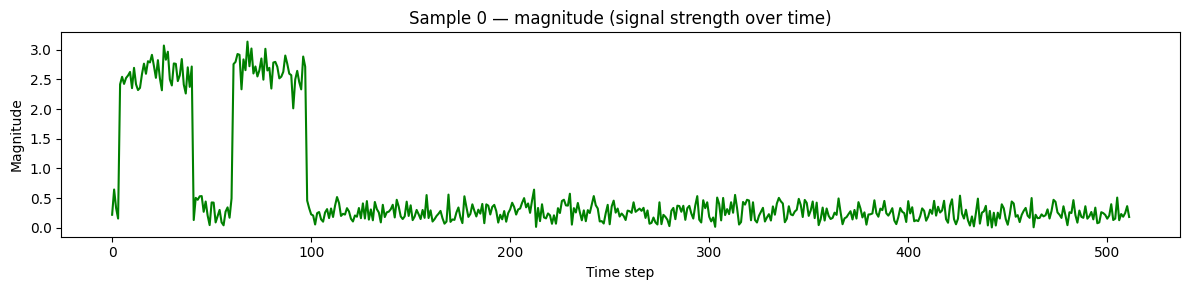

In [4]:
# magnitude = sqrt(I² + Q²) — collapses I and Q into one line showing signal strength over time
sample = iq[0]
magnitude = np.abs(sample)  # numpy does sqrt(I² + Q²) for complex numbers

plt.figure(figsize=(12, 3))
plt.plot(magnitude, color='green')
plt.title(f'Sample 0 — magnitude (signal strength over time)')
plt.xlabel('Time step')
plt.ylabel('Magnitude')
plt.tight_layout()
plt.show()

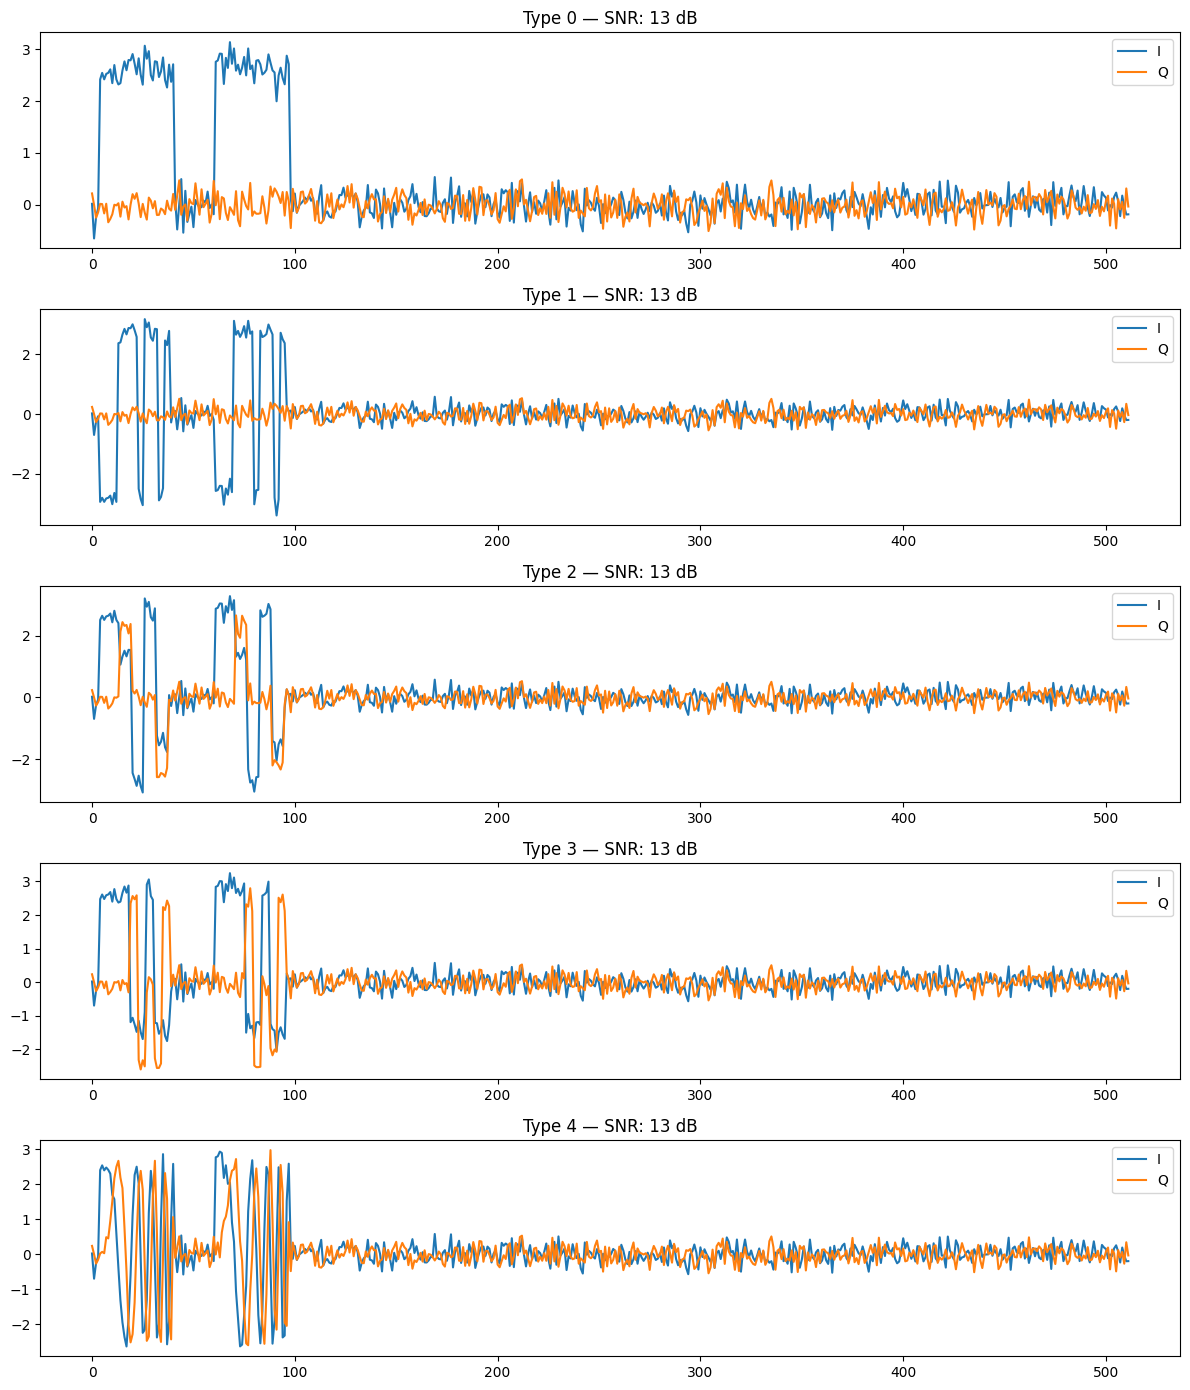

In [5]:
# plot one sample from each signal type so we can compare them
fig, axes = plt.subplots(5, 1, figsize=(12, 14))

for signal_type in range(5):
    # find the first sample of this type
    idx = np.where(labels['signal_type'] == signal_type)[0][0]
    sample = iq[idx]

    I = sample.real
    Q = sample.imag

    axes[signal_type].plot(I, label='I')
    axes[signal_type].plot(Q, label='Q')
    axes[signal_type].set_title(f'Type {signal_type} — SNR: {labels[idx]["signal_to_noise_ratio"]} dB')
    axes[signal_type].legend(loc='upper right')

plt.tight_layout()
plt.show()

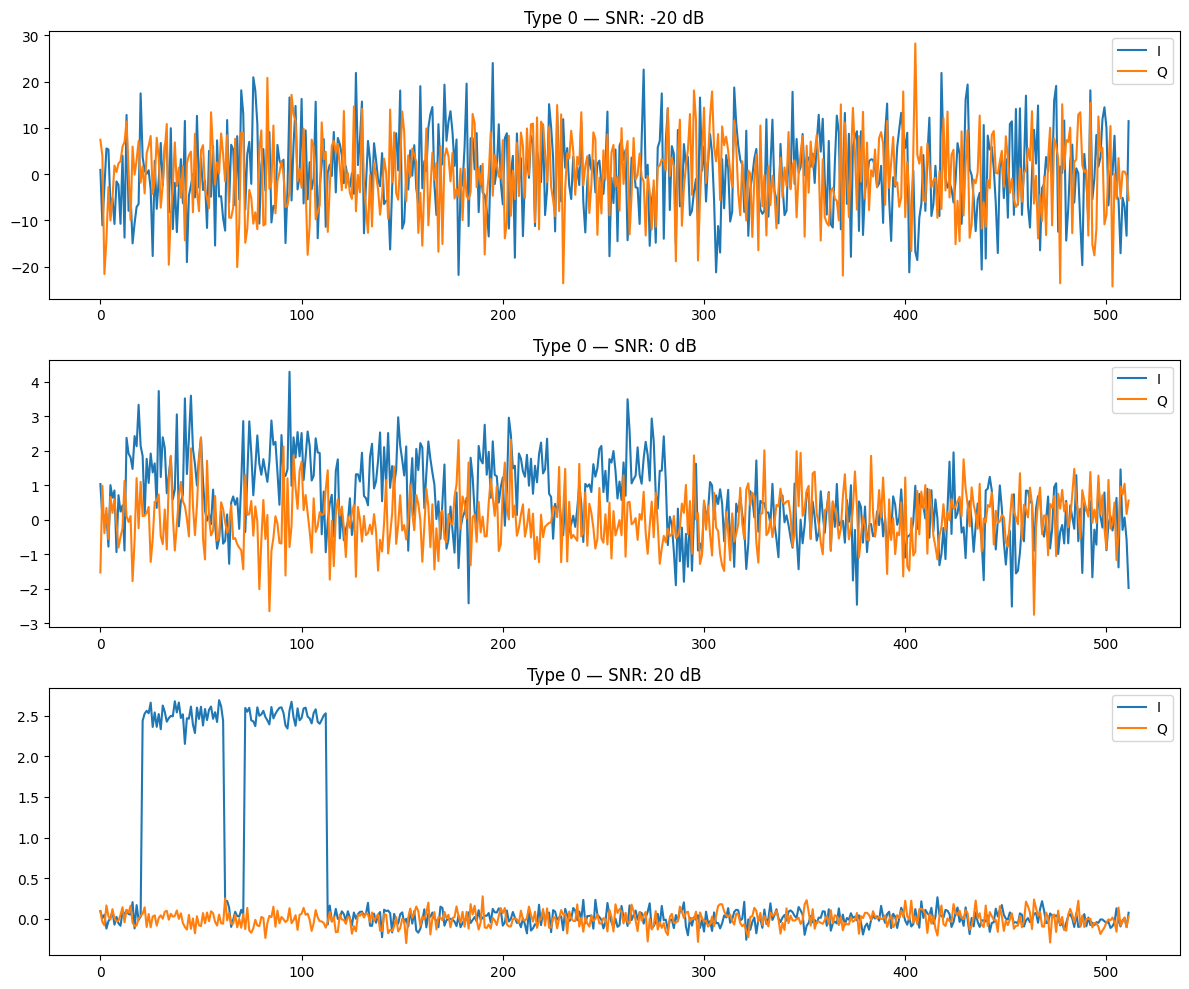

In [6]:
# same signal type, but at different noise levels — see how SNR affects the signal
target_type = 0
samples_of_type = np.where(labels['signal_type'] == target_type)[0]

# sort by SNR and pick low, medium, high
snr_values = labels[samples_of_type]['signal_to_noise_ratio']
sorted_idx = samples_of_type[np.argsort(snr_values)]

low_snr  = sorted_idx[0]     # noisiest
mid_snr  = sorted_idx[len(sorted_idx) // 2]
high_snr = sorted_idx[-1]    # cleanest

fig, axes = plt.subplots(3, 1, figsize=(12, 10))

for i, idx in enumerate([low_snr, mid_snr, high_snr]):
    I = iq[idx].real
    Q = iq[idx].imag
    snr = labels[idx]['signal_to_noise_ratio']
    axes[i].plot(I, label='I')
    axes[i].plot(Q, label='Q')
    axes[i].set_title(f'Type {target_type} — SNR: {snr} dB')
    axes[i].legend(loc='upper right')

plt.tight_layout()
plt.show()